In [1]:
from IPython.display import display, HTML

display(HTML("""
<style>

/* =========================
   전체 레이아웃
========================= */

div.container{
    width:85% !important;
}

div.cell.code_cell.rendered{
    width:100%;
}

div.input_prompt{
    padding:0;
}

div.prompt{
    min-width:70px;
}

div#toc-wrapper{
    padding-top:120px;
}

table.dataframe{
    font-size:12px;
}

/* =========================
   코드 입력창
========================= */

div.CodeMirror{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
    line-height:1.6;
}

/* =========================
   입력 셀
========================= */

div.input{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
}

/* =========================
   코드 출력
========================= */

div.output{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
}

/* =========================
   Markdown 전체
========================= */

.rendered_html{
    font-family:"마루 부리OTF 중간" !important;
    font-size:18px !important;
    line-height:1.8;
}

/* 제목 */
.rendered_html h1,
.rendered_html h2,
.rendered_html h3,
.rendered_html h4,
.rendered_html h5,
.rendered_html h6{
    font-family:"마루 부리OTF 조금굵은" !important;
}

/* 본문 */
.rendered_html p{
    font-family:"마루 부리OTF 중간" !important;
}

/* 리스트 */
.rendered_html li{
    font-family:"마루 부리OTF 중간" !important;
    padding:5px;
}

/* 인용 */
.rendered_html blockquote{
    font-family:"마루 부리OTF 중간" !important;
}

/* 표 */
.rendered_html table{
    font-family:"마루 부리OTF 중간" !important;
}

/* 코드 블록 */
.rendered_html pre,
.rendered_html code{
    font-family:"Consolas" !important;
    font-size:12pt !important;
}

</style>
"""))

In [15]:
import numpy as np
import pandas as pd
import seaborn as sns # iris(데이터프레임)가져오기
from sklearn import datasets # iris(X와 y가 분리되서 numpy) 가져오기
from sklearn.preprocessing import LabelEncoder # 라벨 인코더
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import Input, Dense, LeakyReLU, Dropout

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, Callback, ReduceLROnPlateau
from matplotlib import pyplot as plt

```
- 데이터셋 생성 및 전처리
        X, y(라벨인코딩)분리 -> train_test_split 분리(8:2)
- 모델 구성(입력4, 출력3, layer : 4 -> 64 -> 128 -> 50 -> 30 -> 3 )
- 학습과정 설정 (loss='sparse_categorical_crossentropy')
- 학습
- 모델평가(가장 최선의 모델을 get)
- 모델 사용(저장/예측)
```
# 1. 기본 DNN
## 1. 데이터 셋 생성 및 전처리

In [17]:
# iris 가져오기 방법 1
iris = sns.load_dataset('iris')
iris['species'].value_counts()

setosa        50
versicolor    50
virginica     50
Name: species, dtype: int64

In [20]:
iris_X = iris.iloc[:, :-1].values
labelEncoder = LabelEncoder()
iris_y = labelEncoder.fit_transform(iris.iloc[:, -1]) # 0: setosa / 1: versicolor / 2: virginica
iris_X.shape, iris_y.shape

((150, 4), (150,))

In [24]:
# iris 가져오기 방법 2
iris = datasets.load_iris()
iris_X = iris.data
iris_y = iris.target 
print(iris.target_names)
iris_X.shape, iris_y.shape

['setosa' 'versicolor' 'virginica']


((150, 4), (150,))

In [28]:
# 학습셋과 테스트셋 분리
train_X, test_X, train_y, test_y = train_test_split(iris_X, iris_y, test_size=0.2, 
                                                    stratify=iris_y # 층화추출
                                                   )

In [29]:
np.c_[pd.Series(iris_y).value_counts(normalize=True),
          pd.Series(train_y).value_counts(normalize=True),
          pd.Series(test_y).value_counts(normalize=True) ]

array([[0.33333333, 0.33333333, 0.33333333],
       [0.33333333, 0.33333333, 0.33333333],
       [0.33333333, 0.33333333, 0.33333333]])

In [30]:
train_X.shape, train_y.shape, test_X.shape, test_y.shape

((120, 4), (120,), (30, 4), (30,))

## 2. 모델 구성 및 학습
- 4 -> 64 -> 128 -> 50 -> 30 -> 3
- He초기화, 다양한 activation, 배치정규화, L2정규화, Dropout

In [33]:
model = Sequential([
    Input(4),
    Dense(units=64, activation='relu'),
    Dense(units=128, activation='relu'),
    Dense(units=50, activation='relu'),
    Dense(units=30, activation='relu'),
    Dense(units=3, activation='softmax'),
], 'sequential')
# model = Sequential(name='sequential')
# model.add(Input(4))
# model.add(Dense(units=64, activation='relu'))
# model.add(Dense(units=128, activation='relu'))
# model.add(Dense(units=50, activation='relu'))
# model.add(Dense(units=30, activation='relu'))
# model.add(Dense(units=3, activation='softmax'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 64)                320       
                                                                 
 dense_7 (Dense)             (None, 128)               8320      
                                                                 
 dense_8 (Dense)             (None, 50)                6450      
                                                                 
 dense_9 (Dense)             (None, 30)                1530      
                                                                 
 dense_10 (Dense)            (None, 3)                 93        
                                                                 
Total params: 16,713
Trainable params: 16,713
Non-trainable params: 0
_________________________________________________________________


In [39]:
%%time
model.compile(loss='sparse_categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])
earlystopping = EarlyStopping(patience=40) # monitor='val_loss'가 기본값

model_save_folder = 'model/'
import os
if not os.path.exists(model_save_folder):
    os.mkdir(model_save_folder)
file = model_save_folder + 'iris-{epoch:03d}-loss{val_loss:.4f}-acc{val_accuracy:.4f}.h5'    

checkpoint = ModelCheckpoint(monitor='val_accuracy',
                            filepath=file, # 모델 저장 파일
                            save_best_only=True, # 모니터 지표가 개선된 경우만 모델 저장
                            mode='max',
                            verbose=1 ) # 저장여부 로그 출력

hist = model.fit(train_X, train_y, 
                 epochs=200, 
                 validation_split=0.1, 
                 callbacks=[earlystopping, checkpoint], 
                 verbose=1
                )

Epoch 1/200
1/4 [======>.......................] - ETA: 1s - loss: 0.0154 - accuracy: 1.0000
Epoch 1: val_accuracy improved from -inf to 1.00000, saving model to model\iris-001-loss0.0024-acc1.0000.h5
4/4 [==============================] - 1s 101ms/step - loss: 0.0828 - accuracy: 0.9630 - val_loss: 0.0024 - val_accuracy: 1.0000
Epoch 2/200
1/4 [======>.......................] - ETA: 0s - loss: 0.1010 - accuracy: 0.9375
Epoch 2: val_accuracy did not improve from 1.00000
4/4 [==============================] - 0s 15ms/step - loss: 0.0624 - accuracy: 0.9630 - val_loss: 0.0247 - val_accuracy: 1.0000
Epoch 3/200
1/4 [======>.......................] - ETA: 0s - loss: 0.0128 - accuracy: 1.0000
Epoch 3: val_accuracy did not improve from 1.00000
4/4 [==============================] - 0s 13ms/step - loss: 0.0269 - accuracy: 0.9907 - val_loss: 0.0025 - val_accuracy: 1.0000
Epoch 4/200
1/4 [======>.......................] - ETA: 0s - loss: 0.0190 - accuracy: 1.0000
Epoch 4: val_accuracy did not imp

Epoch 31/200
1/4 [======>.......................] - ETA: 0s - loss: 0.0259 - accuracy: 1.0000
Epoch 31: val_accuracy did not improve from 1.00000
4/4 [==============================] - 0s 12ms/step - loss: 0.0248 - accuracy: 0.9907 - val_loss: 0.0130 - val_accuracy: 1.0000
Epoch 32/200
1/4 [======>.......................] - ETA: 0s - loss: 0.0094 - accuracy: 1.0000
Epoch 32: val_accuracy did not improve from 1.00000
4/4 [==============================] - 0s 21ms/step - loss: 0.0318 - accuracy: 0.9815 - val_loss: 0.0123 - val_accuracy: 1.0000
Epoch 33/200
1/4 [======>.......................] - ETA: 0s - loss: 0.0078 - accuracy: 1.0000
Epoch 33: val_accuracy did not improve from 1.00000
4/4 [==============================] - 0s 17ms/step - loss: 0.0244 - accuracy: 0.9907 - val_loss: 0.0050 - val_accuracy: 1.0000
Epoch 34/200
1/4 [======>.......................] - ETA: 0s - loss: 0.0152 - accuracy: 1.0000
Epoch 34: val_accuracy did not improve from 1.00000
4/4 [===========================

Epoch 61/200
1/4 [======>.......................] - ETA: 0s - loss: 0.0238 - accuracy: 1.0000
Epoch 61: val_accuracy did not improve from 1.00000
4/4 [==============================] - 0s 14ms/step - loss: 0.0338 - accuracy: 0.9907 - val_loss: 0.0017 - val_accuracy: 1.0000
Epoch 62/200
1/4 [======>.......................] - ETA: 0s - loss: 0.0601 - accuracy: 0.9688
Epoch 62: val_accuracy did not improve from 1.00000
4/4 [==============================] - 0s 11ms/step - loss: 0.0379 - accuracy: 0.9815 - val_loss: 0.0135 - val_accuracy: 1.0000
Epoch 63/200
1/4 [======>.......................] - ETA: 0s - loss: 0.0128 - accuracy: 1.0000
Epoch 63: val_accuracy did not improve from 1.00000
4/4 [==============================] - 0s 13ms/step - loss: 0.0479 - accuracy: 0.9815 - val_loss: 0.0331 - val_accuracy: 1.0000
Epoch 64/200
1/4 [======>.......................] - ETA: 0s - loss: 0.0069 - accuracy: 1.0000
Epoch 64: val_accuracy did not improve from 1.00000
4/4 [===========================

# 3. 모델 평가

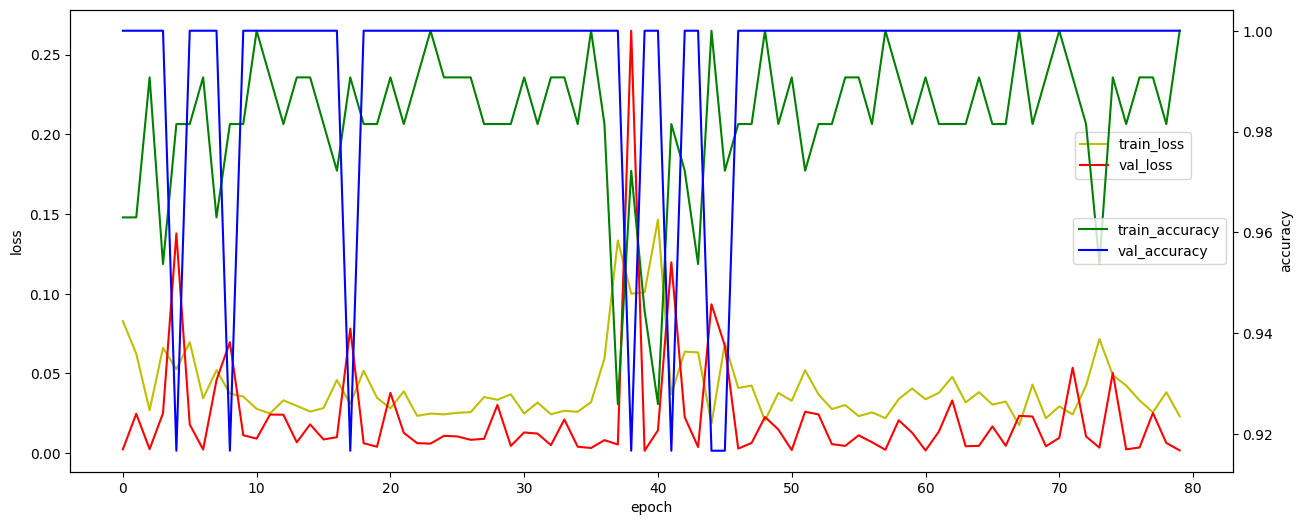

In [43]:
# 학습과정 살펴보기(시각화)
fig, loss_ax = plt.subplots(figsize=(15,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val_loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')

acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(bbox_to_anchor=(0.97,0.75))
acc_ax.legend(loc='center right')
plt.show()

In [44]:
# 모델 평가
loss, acc = model.evaluate(test_X, test_y)
print(loss, acc)

1/1 [==============================] - 0s 22ms/step - loss: 0.1767 - accuracy: 0.9667


[0.17672307789325714, 0.9666666388511658]

In [46]:
# 저장된 모델중 최선 모델
model1 = load_model('model/iris-001-loss0.0024-acc1.0000.h5')
loss1, acc1 = model1.evaluate(test_X, test_y)
print(loss1, acc1)

1/1 [==============================] - 0s 121ms/step - loss: 0.1696 - accuracy: 0.9333
0.16959674656391144 0.9333333373069763


# 2. sklearn이용
- 4 -> 64 -> 128 -> 50 -> 30 -> 3

In [48]:
from sklearn.neural_network import MLPClassifier # multi-Layer perceptron
# 1. 데이터
train_X.shape, train_y.shape, test_X.shape, test_y.shape

((120, 4), (120,), (30, 4), (30,))

In [50]:
model = MLPClassifier(hidden_layer_sizes=(64, 128, 50, 30),
                      activation='relu',
                      solver='adam', # 옵티마이저
                      batch_size=40, # 학습시 batch_size
                      early_stopping=True, # 조기 종료 활성화,
                      n_iter_no_change=50, # earlystopping의 patience역할
                      validation_fraction=0.1, # 검증셋 비율
                      max_iter=200,
                      warm_start=False, # True일 경우 이전학습에 이어서 학습
                     )

In [51]:
# 3. 모델 학습
model.fit(train_X, train_y)

,hidden_layer_sizes,"(64, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,40
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,200
,shuffle,True
,random_state,None


In [52]:
# 4. 모델 평가
model.score(test_X, test_y)

0.9666666666666667

In [54]:
# 5. 교차표(혼동행렬)
# 실제값 : test_y
y_hat = model.predict(test_X)
pd.crosstab(test_y, y_hat, rownames=['real'], colnames=['predict'])

predict,0,1,2
real,,,
0,10,0,0
1,0,9,1
2,0,0,10


In [56]:
from sklearn.metrics import confusion_matrix, recall_score, precision_score
confusion_matrix(test_y, y_hat)

array([[10,  0,  0],
       [ 0,  9,  1],
       [ 0,  0, 10]], dtype=int64)

# 3. 클래스를 생성하여 모델 생성함수 사용
- 모델이 복잡할때 사용

In [74]:
class DNNClassifier:
    @staticmethod
    def build(input_dim=4, activation='relu', output_dim=3):
        # 모델 구성
        model = Sequential([
            Input(input_dim),
            Dense(units=50, activation=activation),
            Dense(units=30, activation=activation),
            Dense(units=output_dim, activation='softmax')
        ] )
        # 모델 학습 설정
        model.compile(loss='sparse_categorical_crossentropy',
                     optimizer='adam',
                     metrics=['accuracy'])
        # 모델 return
        return model

In [75]:
# 1. 데이터
print(train_X.shape, train_y.shape, test_X.shape, test_y.shape)

# 2. 모델
model = DNNClassifier.build(input_dim=4, activation='relu', output_dim=3)

# 3. 모델 학습
hist = model.fit(train_X, train_y,
                epochs=50,
                validation_split=0.1,
                verbose=1)

(120, 4) (120,) (30, 4) (30,)
Epoch 1/50
4/4 [==============================] - 1s 75ms/step - loss: 1.1332 - accuracy: 0.3241 - val_loss: 0.9345 - val_accuracy: 0.4167
Epoch 2/50
4/4 [==============================] - 0s 13ms/step - loss: 0.9346 - accuracy: 0.5185 - val_loss: 0.8516 - val_accuracy: 0.6667
Epoch 3/50
4/4 [==============================] - 0s 12ms/step - loss: 0.8534 - accuracy: 0.6667 - val_loss: 0.7985 - val_accuracy: 0.6667
Epoch 4/50
4/4 [==============================] - 0s 11ms/step - loss: 0.7982 - accuracy: 0.7037 - val_loss: 0.7551 - val_accuracy: 0.7500
Epoch 5/50
4/4 [==============================] - 0s 12ms/step - loss: 0.7570 - accuracy: 0.8426 - val_loss: 0.7059 - val_accuracy: 1.0000
Epoch 6/50
4/4 [==============================] - 0s 14ms/step - loss: 0.7161 - accuracy: 0.9815 - val_loss: 0.6517 - val_accuracy: 0.9167
Epoch 7/50
4/4 [==============================] - 0s 12ms/step - loss: 0.6777 - accuracy: 0.8056 - val_loss: 0.6011 - val_accuracy: 0.83

In [76]:
# 모델 평가
loss, accuracy = model.evaluate(test_X, test_y, verbose=0)
print(f'정확도 : {accuracy*100}%')

정확도 : 96.66666388511658%


# 4. 함수형 API
- 

In [81]:
# 기존 model 스타일
model = Sequential(layers=[
    Input(shape=(4,)),
    Dense(units=50, activation='relu'),
    Dense(units=30, activation='relu'),
    Dense(units=3, activation='softmax'),
])
# 기존 model 스타일2
model = Sequential()
model.add(Input(shape=(4,)))
model.add(Dense(units=50, activation='relu'))
model.add(Dense(units=30, activation='relu'))
model.add(Dense(units=3, activation='softmax'))

In [83]:
# 함수형 API 스타일
from tensorflow.keras import Model
input_ = Input(shape=(4,))
layer1 = Dense(units=50, activation='relu')(input_)
layer2 = Dense(units=30, activation='relu')(layer1)
output = Dense(units=3, activation='softmax')(layer2)
model = Model(inputs=input_, outputs=output)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_20 (InputLayer)       [(None, 4)]               0         
                                                                 
 dense_56 (Dense)            (None, 50)                250       
                                                                 
 dense_57 (Dense)            (None, 30)                1530      
                                                                 
 dense_58 (Dense)            (None, 3)                 93        
                                                                 
Total params: 1,873
Trainable params: 1,873
Non-trainable params: 0
_________________________________________________________________


In [86]:
# 4 -> 160 -> 3
model = Sequential([
    Input(shape=(4,)),
    Dense(units=160, activation='relu'),
    Dense(units=3, activation='softmax')
])
# 함수형 API 방식
input_ = Input(shape=(4,))
layer = Dense(units=160, activation='relu')(input_)
output = Dense(units=3, activation='softmax')(layer)
model = Model(inputs=input_, outputs=output)
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_24 (InputLayer)       [(None, 4)]               0         
                                                                 
 dense_65 (Dense)            (None, 160)               800       
                                                                 
 dense_66 (Dense)            (None, 3)                 483       
                                                                 
Total params: 1,283
Trainable params: 1,283
Non-trainable params: 0
_________________________________________________________________


In [93]:
# 4 -> 160 -> 3를 병렬처리 방식
from tensorflow.keras.layers import Concatenate
input_ = Input(shape=(4,))
dense1 = Dense(units=50, activation='relu')(input_)
dense2 = Dense(units=80, activation='relu')(input_)
dense3 = Dense(units=30, activation='relu')(input_)
x = Concatenate()([dense1, dense2, dense3])
output = Dense(units=3, activation='softmax')(x)
model = Model(inputs=input_, outputs=output)
model.summary()

Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_29 (InputLayer)          [(None, 4)]          0           []                               
                                                                                                  
 dense_81 (Dense)               (None, 50)           250         ['input_29[0][0]']               
                                                                                                  
 dense_82 (Dense)               (None, 80)           400         ['input_29[0][0]']               
                                                                                                  
 dense_83 (Dense)               (None, 30)           150         ['input_29[0][0]']               
                                                                                            

In [97]:
# 레지듀얼 블록 or 잔차블록 (Residual Block)
from tensorflow.keras.layers import add
input_ = Input(shape=(4,))
dense1 = Dense(units=50, activation='relu')(input_)
layer1 = Dense(units=64, activation='relu')(dense1)
layer2 = Dense(units=50, activation='relu')(layer1)
dense2 = add([dense1, layer2])
output = Dense(units=3, activation='softmax')(dense2)
model = Model(inputs=input_, outputs=output)
model.summary()

Model: "model_4"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_32 (InputLayer)          [(None, 4)]          0           []                               
                                                                                                  
 dense_92 (Dense)               (None, 50)           250         ['input_32[0][0]']               
                                                                                                  
 dense_93 (Dense)               (None, 64)           3264        ['dense_92[0][0]']               
                                                                                                  
 dense_94 (Dense)               (None, 50)           3250        ['dense_93[0][0]']               
                                                                                            